# Importing modules and the resnet 34 model

In [11]:

import torchvision.models as models
import numpy as np
import torchvision.transforms as transforms
import torchvision
from torch.utils.data import DataLoader
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os
from torchvision.utils import save_image
pretrained_model = models.resnet34(weights='IMAGENET1K_V1')#pretrained=True downloads the weights
mean_norms = np.array([0.485, 0.456, 0.406])
std_norms = np.array([0.229, 0.224, 0.225])
plain_transforms = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize(mean=mean_norms,
std=std_norms)
])


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
!unzip /content/drive/MyDrive/TestDataSet.zip -d /content/drive/MyDrive

Archive:  /content/drive/MyDrive/TestDataSet.zip
   creating: /content/drive/MyDrive/TestDataSet/
   creating: /content/drive/MyDrive/TestDataSet/n02795169/
  inflating: /content/drive/MyDrive/__MACOSX/TestDataSet/._n02795169  
   creating: /content/drive/MyDrive/TestDataSet/n02769748/
  inflating: /content/drive/MyDrive/__MACOSX/TestDataSet/._n02769748  
   creating: /content/drive/MyDrive/TestDataSet/n02834397/
  inflating: /content/drive/MyDrive/__MACOSX/TestDataSet/._n02834397  
   creating: /content/drive/MyDrive/TestDataSet/n02917067/
  inflating: /content/drive/MyDrive/__MACOSX/TestDataSet/._n02917067  
   creating: /content/drive/MyDrive/TestDataSet/n02808304/
  inflating: /content/drive/MyDrive/__MACOSX/TestDataSet/._n02808304  
   creating: /content/drive/MyDrive/TestDataSet/n03016953/
  inflating: /content/drive/MyDrive/__MACOSX/TestDataSet/._n03016953  
   creating: /content/drive/MyDrive/TestDataSet/n02793495/
  inflating: /content/drive/MyDrive/__MACOSX/TestDataSet/._n027

In [4]:
dataset_path = "/content/drive/MyDrive/TestDataSet"
dataset = torchvision.datasets.ImageFolder(root=dataset_path,transform=plain_transforms)
new_targets = [label + 401 for label in dataset.targets]

# Update both `targets` and `samples` in-place
dataset.targets = new_targets
dataset.samples = [(path, new_label) for (path, _), new_label in zip(dataset.samples, new_targets)]
dataset.imgs = dataset.samples  # Also update imgs, which ImageFolder aliases to samples

dataloader = DataLoader(dataset, batch_size=16, shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

pretrained_model.to(device)
pretrained_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [5]:
import json
with open('/content/drive/MyDrive/TestDataSet/labels_list.json', 'r') as f:
    idx_to_label = json.load(f)
    idx_to_label = {int(x.split(':')[0]): x.split(':')[1].strip() for x in idx_to_label}

## Original dataset verification on resnet34

In [6]:
top1_correct = 0
top5_correct = 0
total_samples = 0
pretrained_model.to(device)

with torch.no_grad():
  for images,labels in dataloader:
    images = images.to(device)
    labels = labels.to(device)
    images.requires_grad = True
    outputs = pretrained_model(images)
    # Get top-5 predictions
    top5_prob, top5_indices = torch.topk(outputs, k=5, dim=1)  # Shape: [batch_size, 5]

    top1_preds = top5_indices[:, 0]
    # Compare actual and predicted labels using string class names
    for i in range(labels.size(0)):
        true_label_idx = labels[i].item()
        true_label_name = idx_to_label[true_label_idx]

        top1_pred_idx = top1_preds[i].item()
        top1_label_name = idx_to_label.get(top1_pred_idx, "")

        if top1_label_name == true_label_name:
            top1_correct += 1

        # Check if true label is in top-5 predictions
        top5_pred_indices = top5_indices[i].tolist()
        top5_label_names = [idx_to_label.get(idx, "") for idx in top5_pred_indices]

        if true_label_name in top5_label_names:
            top5_correct += 1

    total_samples += labels.size(0)

# Final accuracy computation
top1_acc = top1_correct / total_samples * 100
top5_acc = top5_correct / total_samples * 100

print(f"Total samples: {total_samples}")
print(f"Top-1 Accuracy: {top1_acc:.2f}%")
print(f"Top-5 Accuracy: {top5_acc:.2f}%")

Total samples: 500
Top-1 Accuracy: 76.00%
Top-5 Accuracy: 94.20%


## Verifying the accuracy of the original dataset on resnet34

447


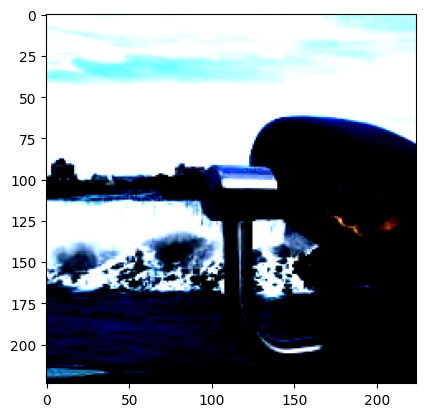

Predicted label index : tensor([447], device='cuda:0')
Predicted Label: binoculars
Confidence: 0.9867
True Label Index: 447
True Label Name: binoculars
425


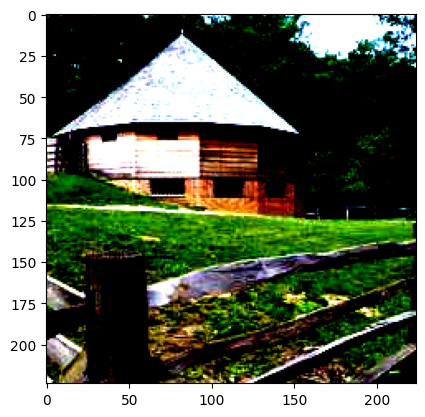

Predicted label index : tensor([912], device='cuda:0')
Predicted Label: Unknown
Confidence: 0.9580
True Label Index: 425
True Label Name: barn
492


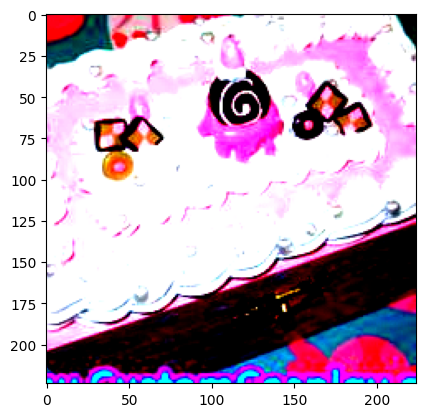

Predicted label index : tensor([492], device='cuda:0')
Predicted Label: chest
Confidence: 0.5144
True Label Index: 492
True Label Name: chest


In [7]:
dataset = dataloader.dataset

# Access the 234th image and its label from the dataset
random_indices = [234,123,456]
for id in random_indices:
  image, label = dataset[id]
  print(label)
  plt.imshow(image.detach().cpu().numpy().transpose(1, 2, 0)),
  plt.show()
  with torch.no_grad():
      image = image.unsqueeze(0).to(device)
      outputs = pretrained_model(image)

  # Get the probabilities by applying softmax
  probabilities = F.softmax(outputs, dim=1)

  # Get the top prediction index and its probability
  confidence, predicted_idx = torch.max(probabilities, 1)

  # Convert the predicted index to the class label name
  predicted_label = idx_to_label.get(predicted_idx.item(), "Unknown")
  print(f"Predicted label index : {predicted_idx}")
  print(f"Predicted Label: {predicted_label}")
  print(f"Confidence: {confidence.item():.4f}")
  print(f"True Label Index: {label}")
  print(f"True Label Name: {idx_to_label.get(label, 'Unknown')}")


# FGSM attack and checking the accuracy of FGSM dataset

In [8]:
import torch.nn.functional as F

pretrained_model.to(device)

epsilon = 0.02
perturbed_images = []
perturbed_image_labels = []
for images,labels in dataloader:
  images = images.to(device)
  labels = labels.to(device)
  images.requires_grad = True
  outputs = pretrained_model(images)

  # Use cross-entropy loss for the entire batch

  loss = F.cross_entropy(outputs, labels)
  pretrained_model.zero_grad()
  loss.backward()  # Compute gradients w.r.t. input

  # Now gradients w.r.t. input images are in images.grad
  input_gradients = images.grad.clone().detach()

  perturbed_inputs = images + epsilon * torch.sign(input_gradients)
  perturbed_images.extend(perturbed_inputs)
  perturbed_image_labels.extend(labels)



## Preparing dataloader for FGSM perturbed images

In [10]:
class LoadedPerturbedDataset(torch.utils.data.Dataset):
    def __init__(self, perturbed_images, perturbed_labels):
        self.perturbed_images = perturbed_images
        self.perturbed_labels = perturbed_labels

    def __len__(self):
        return len(self.perturbed_images)

    def __getitem__(self, idx):
        return self.perturbed_images[idx], self.perturbed_labels[idx]

perturbed_dataset = LoadedPerturbedDataset(perturbed_images, perturbed_image_labels)
perturbed_dataloader = DataLoader(perturbed_dataset, batch_size=16, shuffle=False)

## Storing the perturbed images in a separate folder

In [12]:
def save_dataloader_to_folder(dataloader, output_folder, prefix="image"):
    os.makedirs(output_folder, exist_ok=True)

    idx = 0
    for images, labels in dataloader:
        for i in range(images.size(0)):
            image = images[i]
            label = labels[i].item()
            filename = f"{prefix}_{idx}_label_{label}.png"
            filepath = os.path.join(output_folder, filename)

            # If image is normalized, unnormalize before saving
            save_image(image, filepath)  # Assumes image is [0, 1] range
            idx += 1

    print(f"Saved {idx} images to {output_folder}")


In [13]:
save_dataloader_to_folder(perturbed_dataloader, "/content/drive/MyDrive/FGSM_perturbed_images")

Saved 500 images to /content/drive/MyDrive/FGSM_perturbed_images


## Checking the top-1 and top-5 accuracy of the resnet34 model on FGSM dataset

In [14]:
top1_correct_fgsm = 0
top5_correct_fgsm = 0
total_samples_fgsm = 0
total_samples_perturbed = 0
pretrained_model.to(device)

with torch.no_grad():
  for images,labels in perturbed_dataloader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = pretrained_model(images)
    # Get top-5 predictions
    top5_prob, top5_indices = torch.topk(outputs, k=5, dim=1)  # Shape: [batch_size, 5]

    top1_preds = top5_indices[:, 0]
    # Compare actual and predicted labels using string class names
    for i in range(labels.size(0)):
        true_label_idx = labels[i].item()
        true_label_name = idx_to_label[true_label_idx]

        top1_pred_idx = top1_preds[i].item()
        top1_label_name = idx_to_label.get(top1_pred_idx, "")

        if top1_label_name == true_label_name:
            top1_correct_fgsm += 1

        # Check if true label is in top-5 predictions
        top5_pred_indices = top5_indices[i].tolist()
        top5_label_names = [idx_to_label.get(idx, "") for idx in top5_pred_indices]

        if true_label_name in top5_label_names:
            top5_correct_fgsm += 1

    total_samples_perturbed += labels.size(0)

# Final accuracy computation
top1_acc_fgsm = top1_correct_fgsm / total_samples_perturbed * 100
top5_acc_fgsm = top5_correct_fgsm / total_samples_perturbed * 100

print(f"Total samples: {total_samples_perturbed}")
print(f"Top-1 Accuracy: {top1_acc_fgsm:.2f}%")
print(f"Top-5 Accuracy: {top5_acc_fgsm:.2f}%")

Total samples: 500
Top-1 Accuracy: 6.20%
Top-5 Accuracy: 23.60%


## Verifying the efficacy of the FGSM attack on 3 sample images

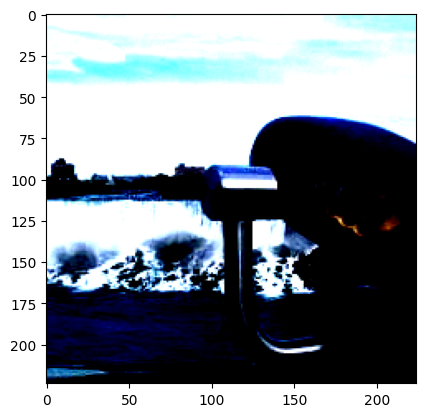

Predicted label index : tensor([600], device='cuda:0')
Predicted Label: Unknown
Confidence: 0.0091
True Label Index: 447
True Label Name: binoculars


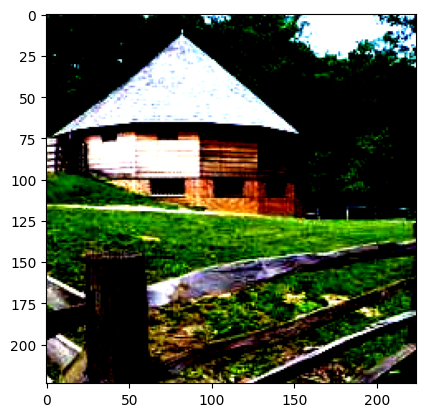

Predicted label index : tensor([463], device='cuda:0')
Predicted Label: bucket
Confidence: 0.0068
True Label Index: 425
True Label Name: barn


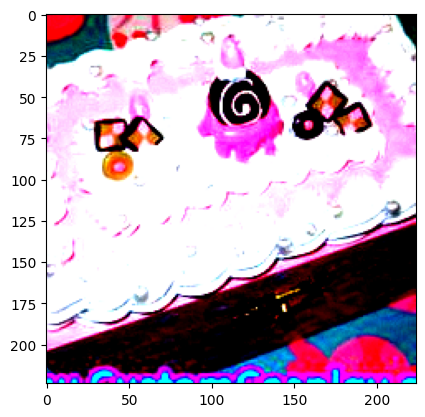

Predicted label index : tensor([463], device='cuda:0')
Predicted Label: bucket
Confidence: 0.0071
True Label Index: 492
True Label Name: chest


In [15]:
perturbed_dataset = perturbed_dataloader.dataset

# Access the 234th image and its label from the dataset
random_indices = [234,123,456]
for id in random_indices:
  image, label = perturbed_dataset[id]
  plt.imshow(image.detach().cpu().numpy().transpose(1, 2, 0)),
  plt.show()
  with torch.no_grad():
      image = image.unsqueeze(0).to(device)
      outputs = pretrained_model(image)

  # Get the probabilities by applying softmax
  probabilities = F.softmax(outputs, dim=1)

  # Get the top prediction index and its probability
  confidence, predicted_idx = torch.max(probabilities, 1)

  # Convert the predicted index to the class label name
  predicted_label = idx_to_label.get(predicted_idx.item(), "Unknown")
  print(f"Predicted label index : {predicted_idx}")
  print(f"Predicted Label: {predicted_label}")
  print(f"Confidence: {confidence.item():.4f}")
  print(f"True Label Index: {label.item()}")
  print(f"True Label Name: {idx_to_label.get(label.item(), 'Unknown')}")


## Verifying that the magnitude of FGSM perturbation for all images is less than or equal to epsilon

In [16]:

import matplotlib.pyplot as plt


original_dataset_aligned = dataloader.dataset

epsilon_check = 0.02

valid_perturbations = 0

for i in range(len(perturbed_dataset)):
  perturbed_image, perturbed_label = perturbed_dataset[i]
  original_image, original_label = original_dataset_aligned[i]
  perturbed_image = perturbed_image.to(device)
  original_image = original_image.to(device)

  # Calculate the difference between perturbed and original image
  difference = perturbed_image - original_image
  # Calculate the L2 norm of the difference
  l2_norm = difference.abs().max()
  # Check if the L2 norm is less than epsilon
  tolerance = 1e-5
  is_within_epsilon = l2_norm < (epsilon_check + tolerance)
  if is_within_epsilon:
    valid_perturbations += 1
  # Optional: Print or store the results
  # print(f"Sample {i}: L2 Norm = {l2_norm.item():.6f}, Within Epsilon ({epsilon_check}) = {is_within_epsilon}")

  # You could add logic here to count how many samples are within the epsilon bound
  # or perform further analysis based on this check.
print(f"Total samples: {len(perturbed_dataset)}")
print(f"Valid perturbations: {valid_perturbations}")
# You can add a summary after the loop if needed
# print(f"\nCompleted L2 norm checks for {len(perturbed_dataset)} samples.")

Total samples: 500
Valid perturbations: 500


# PGD attack on the original dataset and creating dataloader for PGD dataset

In [17]:
def pgd_attack(model, dataloader, epsilon, alpha, num_iterations, device):
    """
    Perform PGD attack on the whole dataloader.
    Returns all perturbed images and labels.
    """
    model.eval()
    adv_images_all = []
    adv_labels_all = []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        original_images = images.clone().detach()

        perturbed_images = images.clone().detach().to(device)
        perturbed_images.requires_grad = True

        for _ in range(num_iterations):
            outputs = model(perturbed_images)
            loss = F.cross_entropy(outputs, labels)

            model.zero_grad()
            loss.backward()

            # Get gradient
            gradients = perturbed_images.grad
            if gradients is None:
                raise ValueError("Gradient is None. Make sure requires_grad=True on the input.")

            # PGD step
            perturbed_images = perturbed_images + alpha * gradients.sign()
            perturbed_images = torch.min(torch.max(perturbed_images, original_images - epsilon), original_images + epsilon)
            perturbed_images = torch.clamp(perturbed_images, original_images - epsilon, original_images + epsilon)

            # Detach to stop accumulating gradient history, and re-enable grad
            perturbed_images = perturbed_images.detach()
            perturbed_images.requires_grad = True

        adv_images_all.append(perturbed_images.detach().cpu())
        adv_labels_all.append(labels.detach().cpu())

    # Concatenate all batches
    adv_images_all = torch.cat(adv_images_all)
    adv_labels_all = torch.cat(adv_labels_all)

    return adv_images_all, adv_labels_all

alpha = 0.005
num_iterations = 10
epsilon = 0.02
pgd_perturbed_images,pgd_labels = pgd_attack(pretrained_model, dataloader, epsilon, alpha, num_iterations, device)


pgd_perturbed_dataset = LoadedPerturbedDataset(pgd_perturbed_images, pgd_labels)
pgd_perturbed_dataloader = DataLoader(pgd_perturbed_dataset, batch_size=16, shuffle=False)



## Storing the PGD dataset in a folder

In [18]:
save_dataloader_to_folder(pgd_perturbed_dataloader, "/content/drive/MyDrive/PGD_perturbed_images")

Saved 500 images to /content/drive/MyDrive/PGD_perturbed_images


## Checking the top-1 and top-5 accuracy of the resnet34 model on PGD dataset

In [19]:
top1_correct_pgd = 0
top5_correct_pgd = 0
total_samples_pgd = 0
total_samples_perturbed_pgd = 0
pretrained_model.to(device)

with torch.no_grad():
  for images,labels in pgd_perturbed_dataloader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = pretrained_model(images)
    # Get top-5 predictions
    top5_prob, top5_indices = torch.topk(outputs, k=5, dim=1)  # Shape: [batch_size, 5]

    top1_preds = top5_indices[:, 0]
    # Compare actual and predicted labels using string class names
    for i in range(labels.size(0)):
        true_label_idx = labels[i].item()
        true_label_name = idx_to_label[true_label_idx]

        top1_pred_idx = top1_preds[i].item()
        top1_label_name = idx_to_label.get(top1_pred_idx, "")

        if top1_label_name == true_label_name:
            top1_correct_pgd += 1

        # Check if true label is in top-5 predictions
        top5_pred_indices = top5_indices[i].tolist()
        top5_label_names = [idx_to_label.get(idx, "") for idx in top5_pred_indices]

        if true_label_name in top5_label_names:
            top5_correct_pgd += 1

    total_samples_perturbed_pgd += labels.size(0)

# Final accuracy computation
top1_acc_pgd = top1_correct_pgd / total_samples_perturbed_pgd * 100
top5_acc_pgd = top5_correct_pgd / total_samples_perturbed_pgd * 100

print(f"Total samples: {total_samples_perturbed_pgd}")
print(f"Top-1 Accuracy: {top1_acc_pgd:.2f}%")
print(f"Top-5 Accuracy: {top5_acc_pgd:.2f}%")

Total samples: 500
Top-1 Accuracy: 0.00%
Top-5 Accuracy: 7.40%


## Verifying the efficacy of the PGD attack on 3 sample images

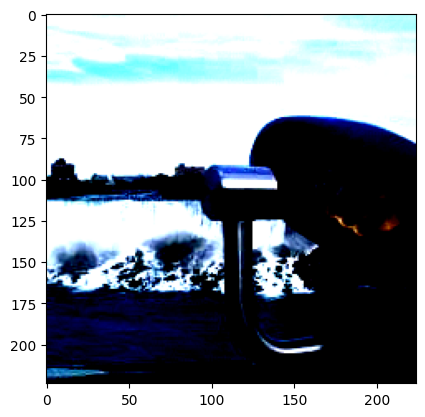

Predicted label index : tensor([693], device='cuda:0')
Predicted Label: Unknown
Confidence: 0.9997
True Label Index: 447
True Label Name: binoculars


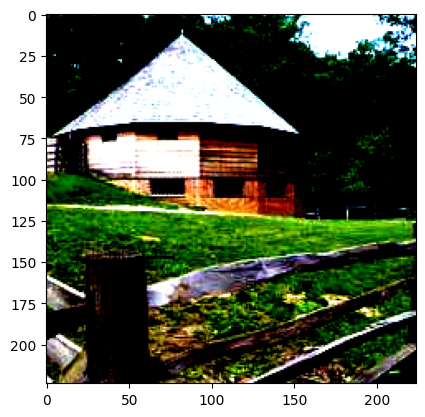

Predicted label index : tensor([912], device='cuda:0')
Predicted Label: Unknown
Confidence: 1.0000
True Label Index: 425
True Label Name: barn


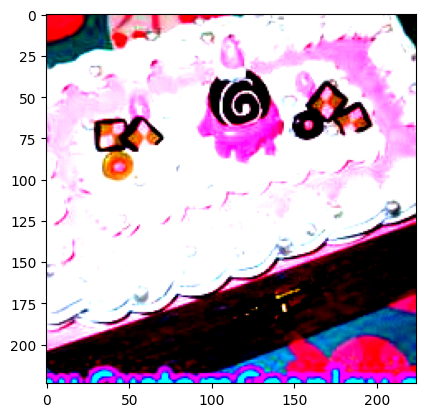

Predicted label index : tensor([793], device='cuda:0')
Predicted Label: Unknown
Confidence: 1.0000
True Label Index: 492
True Label Name: chest


In [20]:
pgd_perturbed_dataset = pgd_perturbed_dataloader.dataset

# Access the 234th image and its label from the dataset
random_indices = [234,123,456]
for id in random_indices:
  image, label = pgd_perturbed_dataset[id]
  plt.imshow(image.detach().cpu().numpy().transpose(1, 2, 0)),
  plt.show()
  with torch.no_grad():
      image = image.unsqueeze(0).to(device)
      outputs = pretrained_model(image)

  # Get the probabilities by applying softmax
  probabilities = F.softmax(outputs, dim=1)

  # Get the top prediction index and its probability
  confidence, predicted_idx = torch.max(probabilities, 1)

  # Convert the predicted index to the class label name
  predicted_label = idx_to_label.get(predicted_idx.item(), "Unknown")
  print(f"Predicted label index : {predicted_idx}")
  print(f"Predicted Label: {predicted_label}")
  print(f"Confidence: {confidence.item():.4f}")
  print(f"True Label Index: {label.item()}")
  print(f"True Label Name: {idx_to_label.get(label.item(), 'Unknown')}")


## Verifying that the magnitude of PGD perturbation for all images is less than or equal to epsilon

In [21]:

import matplotlib.pyplot as plt


original_dataset_aligned = dataloader.dataset

epsilon_check = 0.02

valid_perturbations = 0

for i in range(len(pgd_perturbed_dataset)):
  perturbed_image, perturbed_label = pgd_perturbed_dataset[i]
  original_image, original_label = original_dataset_aligned[i]
  perturbed_image = perturbed_image.to(device)
  original_image = original_image.to(device)

  # Calculate the difference between perturbed and original image
  difference = perturbed_image - original_image
  # Calculate the L2 norm of the difference
  l2_norm = difference.abs().max()
  # Check if the L2 norm is less than epsilon
  tolerance = 1e-5
  is_within_epsilon = l2_norm < (epsilon_check + tolerance)
  if is_within_epsilon:
    valid_perturbations += 1
  # Optional: Print or store the results
  # print(f"Sample {i}: L2 Norm = {l2_norm.item():.6f}, Within Epsilon ({epsilon_check}) = {is_within_epsilon}")

  # You could add logic here to count how many samples are within the epsilon bound
  # or perform further analysis based on this check.
print(f"Total samples: {len(perturbed_dataset)}")
print(f"Valid perturbations: {valid_perturbations}")
# You can add a summary after the loop if needed
# print(f"\nCompleted L2 norm checks for {len(perturbed_dataset)} samples.")

Total samples: 500
Valid perturbations: 500


# Random patched PGD attack on the original dataset and creating dataloader for random patched PGD dataset


This is the method which we researched and is a bit different from standard patched attacks. In PGD we perform multiple iterations, and in each iteration of PGD, this algorithm uniformly randomly chooses a 32*32 patch and perturbs that patch, this way the net change performed on the image is very less, and the final image doesn't have any ugly patch, it's very less deviant formt he original image and we can achieve much better attack, it's the best attack which we propose in this project

In [22]:
import random

def random_patched_pgd_attack(model, dataloader, epsilon, alpha, num_iterations, device):
    """
    Perform PGD attack on the whole dataloader.
    Returns all perturbed images and labels.
    """
    model.eval()
    adv_images_all = []
    adv_labels_all = []


    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        original_images = images.clone().detach()
        print(images.shape)
        perturbed_images = images.clone().detach().to(device)
        perturbed_images.requires_grad = True

        for _ in range(num_iterations):
            outputs = model(perturbed_images)
            loss = F.cross_entropy(outputs, labels)

            model.zero_grad()
            loss.backward()

            # Get gradient
            gradients = perturbed_images.grad
            if gradients is None:
                raise ValueError("Gradient is None. Make sure requires_grad=True on the input.")

            # Randomized patched PGD step
            patch_perturbed_images = []
            for img_num,perturbed_image in enumerate(perturbed_images):
              copied_image = perturbed_image.clone().detach()
              original_perturbed_image = perturbed_image.clone().detach()
              rand_x = random.randint(0, perturbed_image.shape[1] - 32)
              rand_y = random.randint(0, perturbed_image.shape[2] - 32)
              patch = perturbed_image[:, rand_x:rand_x+32, rand_y:rand_y+32]+alpha * gradients.sign()[img_num,:, rand_x:rand_x+32, rand_y:rand_y+32]
              patch = torch.min(torch.max(patch, original_perturbed_image[:,rand_x:rand_x+32,rand_y:rand_y+32] - epsilon), original_perturbed_image[:,rand_x:rand_x+32,rand_y:rand_y+32] + epsilon)
              patch = torch.clamp(patch, original_images[img_num,:,rand_x:rand_x+32,rand_y:rand_y+32] - epsilon, original_images[img_num,:,rand_x:rand_x+32,rand_y:rand_y+32] + epsilon)
              copied_image[:, rand_x:rand_x+32, rand_y:rand_y+32] = patch

              patch_perturbed_images.append(copied_image)

            perturbed_images = torch.stack(patch_perturbed_images)
            # Detach to stop accumulating gradient history, and re-enable grad
            perturbed_images = perturbed_images.detach()
            perturbed_images.requires_grad = True

        adv_images_all.append(perturbed_images.detach().cpu())
        adv_labels_all.append(labels.detach().cpu())
        # Concatenate all batches
    adv_images_all = torch.cat(adv_images_all)
    adv_labels_all = torch.cat(adv_labels_all)

    return adv_images_all, adv_labels_all




alpha = 0.005
num_iterations =  500
epsilon = 0.5
patched_random_pgd_perturbed_images,patched_random_pgd_labels = random_patched_pgd_attack(pretrained_model, dataloader, epsilon, alpha, num_iterations, device)


patched_random_pgd_perturbed_dataset = LoadedPerturbedDataset(patched_random_pgd_perturbed_images, patched_random_pgd_labels)
patched_random_pgd_perturbed_dataloader = DataLoader(patched_random_pgd_perturbed_dataset, batch_size=16, shuffle=False)



torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([4, 3, 224, 224])


## Storing the Random patched PGD dataset in a folder

In [23]:
save_dataloader_to_folder(patched_random_pgd_perturbed_dataloader, "/content/drive/MyDrive/patched_random_PGD_perturbed_images")

Saved 500 images to /content/drive/MyDrive/patched_random_PGD_perturbed_images


## Checking the top-1 and top-5 accuracy of the resnet34 model on Random patched PGD dataset

In [24]:
random_patched_pgd_perturtop1_correct_patched_pgd = 0
top1_correct_random_patched_pgd = 0
top5_correct_random_patched_pgd = 0
total_samples_perturbed_random_patched_pgd = 0
pretrained_model.to(device)

with torch.no_grad():
  for images,labels in patched_random_pgd_perturbed_dataloader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = pretrained_model(images)
    # Get top-5 predictions
    top5_prob, top5_indices = torch.topk(outputs, k=5, dim=1)  # Shape: [batch_size, 5]

    top1_preds = top5_indices[:, 0]
    # Compare actual and predicted labels using string class names
    for i in range(labels.size(0)):
        true_label_idx = labels[i].item()
        true_label_name = idx_to_label[true_label_idx]

        top1_pred_idx = top1_preds[i].item()
        top1_label_name = idx_to_label.get(top1_pred_idx, "")

        if top1_label_name == true_label_name:
            top1_correct_random_patched_pgd += 1

        # Check if true label is in top-5 predictions
        top5_pred_indices = top5_indices[i].tolist()
        top5_label_names = [idx_to_label.get(idx, "") for idx in top5_pred_indices]

        if true_label_name in top5_label_names:
            top5_correct_random_patched_pgd += 1

    total_samples_perturbed_random_patched_pgd += labels.size(0)

# Final accuracy computation
top1_acc_random_patched_pgd = top1_correct_random_patched_pgd / total_samples_perturbed_random_patched_pgd * 100
top5_acc_random_patched_pgd = top5_correct_random_patched_pgd / total_samples_perturbed_random_patched_pgd * 100

print(f"Total samples: {total_samples_perturbed_random_patched_pgd}")
print(f"Top-1 Accuracy: {top1_acc_random_patched_pgd:.2f}%")
print(f"Top-5 Accuracy: {top5_acc_random_patched_pgd:.2f}%")

Total samples: 500
Top-1 Accuracy: 0.00%
Top-5 Accuracy: 1.80%


## Verifying the efficacy of the Randomized patched PGD attack on 3 sample images

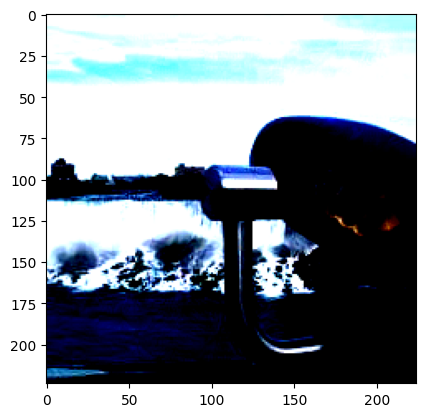

Predicted label index : tensor([693], device='cuda:0')
Predicted Label: Unknown
Confidence: 1.0000
True Label Index: 447
True Label Name: binoculars


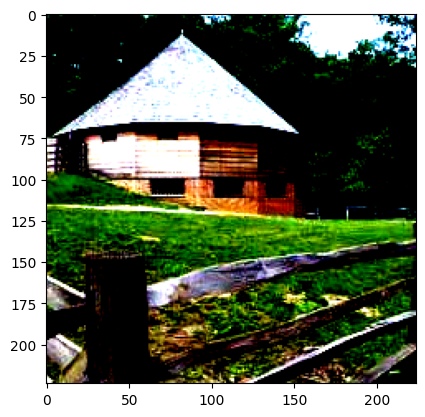

Predicted label index : tensor([912], device='cuda:0')
Predicted Label: Unknown
Confidence: 1.0000
True Label Index: 425
True Label Name: barn


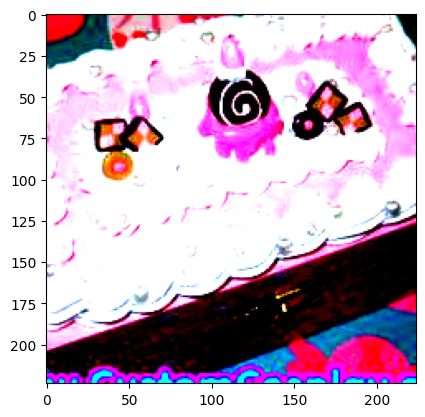

Predicted label index : tensor([584], device='cuda:0')
Predicted Label: Unknown
Confidence: 1.0000
True Label Index: 492
True Label Name: chest


In [25]:
patched_random_pgd_perturbed_dataset = patched_random_pgd_perturbed_dataloader.dataset

# Access the 234th image and its label from the dataset
random_indices = [234,123,456]
for id in random_indices:
  image, label = patched_random_pgd_perturbed_dataset[id]
  plt.imshow(image.detach().cpu().numpy().transpose(1, 2, 0)),
  plt.show()
  with torch.no_grad():
      image = image.unsqueeze(0).to(device)
      outputs = pretrained_model(image)

  # Get the probabilities by applying softmax
  probabilities = F.softmax(outputs, dim=1)

  # Get the top prediction index and its probability
  confidence, predicted_idx = torch.max(probabilities, 1)

  # Convert the predicted index to the class label name
  predicted_label = idx_to_label.get(predicted_idx.item(), "Unknown")
  print(f"Predicted label index : {predicted_idx}")
  print(f"Predicted Label: {predicted_label}")
  print(f"Confidence: {confidence.item():.4f}")
  print(f"True Label Index: {label.item()}")
  print(f"True Label Name: {idx_to_label.get(label.item(), 'Unknown')}")


## Verifying that the magnitude of randomized patched PGD perturbation for all images is less than or equal to epsilon

In [31]:

import matplotlib.pyplot as plt


original_dataset_aligned = dataloader.dataset

epsilon_check = 0.5

valid_perturbations = 0

for i in range(len(pgd_perturbed_dataset)):
  perturbed_image, perturbed_label = patched_random_pgd_perturbed_dataset[i]
  original_image, original_label = original_dataset_aligned[i]
  perturbed_image = perturbed_image.to(device)
  original_image = original_image.to(device)

  # Calculate the difference between perturbed and original image
  difference = perturbed_image - original_image

  # Calculate the L2 norm of the difference
  l2_norm = difference.abs().max()
  # Check if the L2 norm is less than epsilon
  tolerance = 1e-5
  is_within_epsilon = l2_norm < (epsilon_check + tolerance)
  if is_within_epsilon:
    valid_perturbations += 1
  # Optional: Print or store the results
  # print(f"Sample {i}: L2 Norm = {l2_norm.item():.6f}, Within Epsilon ({epsilon_check}) = {is_within_epsilon}")

  # You could add logic here to count how many samples are within the epsilon bound
  # or perform further analysis based on this check.
print(f"Total samples: {len(perturbed_dataset)}")
print(f"Valid perturbations: {valid_perturbations}")
# You can add a summary after the loop if needed
# print(f"\nCompleted L2 norm checks for {len(perturbed_dataset)} samples.")

Total samples: 500
Valid perturbations: 500


# Patched PGD attack and preparing the dataloader for the new dataset

In this attack, we analysed the images and for many images, we found that the key element which helps the classifier to classify the image is at the center or around the center, so we decided to focus all the perturbation around the center and this worked efficienty, as we can see in the subsequent cells

In [32]:
import random

def patched_pgd_attack(model, dataloader, epsilon, alpha, num_iterations, device):
    """
    Perform PGD attack on the whole dataloader.
    Returns all perturbed images and labels.
    """
    model.eval()
    adv_images_all = []
    adv_labels_all = []


    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)
        original_images = images.clone().detach()
        print(images.shape)
        perturbed_images = images.clone().detach().to(device)
        perturbed_images.requires_grad = True

        random_patch_each_image = {}

        for img_num,perturbed_image in enumerate(perturbed_images):
          rand_x = random.randint(0, perturbed_image.shape[1] - 32)
          rand_y = random.randint(0, perturbed_image.shape[2] - 32)
          random_patch_each_image[img_num] = (rand_x,rand_y)

        for _ in range(num_iterations):
            outputs = model(perturbed_images)
            loss = F.cross_entropy(outputs, labels)

            model.zero_grad()
            loss.backward()

            # Get gradient
            gradients = perturbed_images.grad
            if gradients is None:
                raise ValueError("Gradient is None. Make sure requires_grad=True on the input.")

            # Randomized patched PGD step
            patch_perturbed_images = []
            for img_num,perturbed_image in enumerate(perturbed_images):
              copied_image = perturbed_image.clone().detach()
              original_perturbed_image = perturbed_image.clone().detach()
              rand_x = 122-16
              rand_y = 122-16
              patch = perturbed_image[:, rand_x:rand_x+32, rand_y:rand_y+32]+alpha * gradients.sign()[img_num,:, rand_x:rand_x+32, rand_y:rand_y+32]
              patch = torch.min(torch.max(patch, original_perturbed_image[:,rand_x:rand_x+32,rand_y:rand_y+32] - epsilon), original_perturbed_image[:,rand_x:rand_x+32,rand_y:rand_y+32] + epsilon)
              patch = torch.clamp(patch, original_images[img_num,:,rand_x:rand_x+32,rand_y:rand_y+32] - epsilon, original_images[img_num,:,rand_x:rand_x+32,rand_y:rand_y+32] + epsilon)
              copied_image[:, rand_x:rand_x+32, rand_y:rand_y+32] = patch

              patch_perturbed_images.append(copied_image)

            perturbed_images = torch.stack(patch_perturbed_images)
            # Detach to stop accumulating gradient history, and re-enable grad
            perturbed_images = perturbed_images.detach()
            perturbed_images.requires_grad = True

        adv_images_all.append(perturbed_images.detach().cpu())
        adv_labels_all.append(labels.detach().cpu())
        # Concatenate all batches
    adv_images_all = torch.cat(adv_images_all)
    adv_labels_all = torch.cat(adv_labels_all)

    return adv_images_all, adv_labels_all




alpha = 0.05
num_iterations =  500
epsilon = 0.5
patched_pgd_perturbed_images,patched_pgd_labels = patched_pgd_attack(pretrained_model, dataloader, epsilon, alpha, num_iterations, device)


patched_pgd_perturbed_dataset = LoadedPerturbedDataset(patched_pgd_perturbed_images, patched_pgd_labels)
patched_pgd_perturbed_dataloader = DataLoader(patched_pgd_perturbed_dataset, batch_size=16, shuffle=False)



torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([16, 3, 224, 224])
torch.Size([4, 3, 224, 224])


## Storing the patched PGD dataset in a separate folder

In [33]:
save_dataloader_to_folder(patched_pgd_perturbed_dataloader, "/content/drive/MyDrive/patched_center_masked_PGD_perturbed_images")

Saved 500 images to /content/drive/MyDrive/patched_center_masked_PGD_perturbed_images


## Calculating the top-1 and top-5 accuracy for the patched PGD dataset

In [34]:
top1_correct_patched_pgd = 0
top5_correct_patched_pgd = 0
total_samples_patched_pgd = 0
total_samples_perturbed_patched_pgd = 0
pretrained_model.to(device)

with torch.no_grad():
  for images,labels in patched_pgd_perturbed_dataloader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = pretrained_model(images)
    # Get top-5 predictions
    top5_prob, top5_indices = torch.topk(outputs, k=5, dim=1)  # Shape: [batch_size, 5]

    top1_preds = top5_indices[:, 0]
    # Compare actual and predicted labels using string class names
    for i in range(labels.size(0)):
        true_label_idx = labels[i].item()
        true_label_name = idx_to_label[true_label_idx]

        top1_pred_idx = top1_preds[i].item()
        top1_label_name = idx_to_label.get(top1_pred_idx, "")

        if top1_label_name == true_label_name:
            top1_correct_patched_pgd += 1

        # Check if true label is in top-5 predictions
        top5_pred_indices = top5_indices[i].tolist()
        top5_label_names = [idx_to_label.get(idx, "") for idx in top5_pred_indices]

        if true_label_name in top5_label_names:
            top5_correct_patched_pgd += 1

    total_samples_perturbed_patched_pgd += labels.size(0)

# Final accuracy computation
top1_acc_patched_pgd = top1_correct_patched_pgd / total_samples_perturbed_patched_pgd * 100
top5_acc_patched_pgd = top5_correct_patched_pgd / total_samples_perturbed_patched_pgd * 100

print(f"Total samples: {total_samples_perturbed_patched_pgd}")
print(f"Top-1 Accuracy: {top1_acc_patched_pgd:.2f}%")
print(f"Top-5 Accuracy: {top5_acc_patched_pgd:.2f}%")

Total samples: 500
Top-1 Accuracy: 4.00%
Top-5 Accuracy: 29.40%


## Verifying the efficacy of the patched PGD attack on 3 sample images, these images contain the perturbed patch at the center of the image

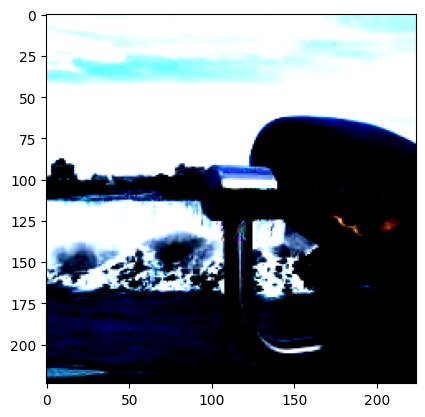

Predicted label index : tensor([589], device='cuda:0')
Predicted Label: Unknown
Confidence: 0.9983
True Label Index: 447
True Label Name: binoculars


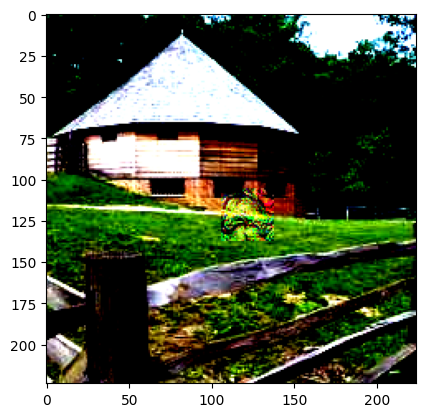

Predicted label index : tensor([912], device='cuda:0')
Predicted Label: Unknown
Confidence: 0.9764
True Label Index: 425
True Label Name: barn


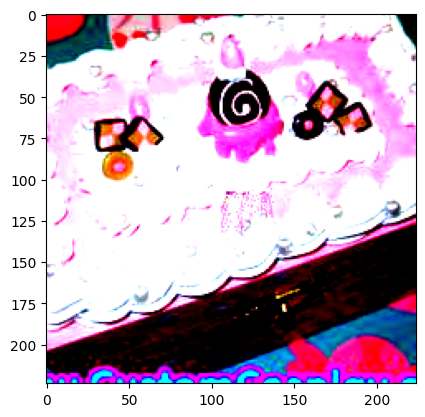

Predicted label index : tensor([584], device='cuda:0')
Predicted Label: Unknown
Confidence: 0.9636
True Label Index: 492
True Label Name: chest


In [35]:
patched_pgd_perturbed_dataset = patched_pgd_perturbed_dataloader.dataset

# Access the 234th image and its label from the dataset
random_indices = [234,123,456]
for id in random_indices:
  image, label = patched_pgd_perturbed_dataset[id]
  plt.imshow(image.detach().cpu().numpy().transpose(1, 2, 0)),
  plt.show()
  with torch.no_grad():
      image = image.unsqueeze(0).to(device)
      outputs = pretrained_model(image)

  # Get the probabilities by applying softmax
  probabilities = F.softmax(outputs, dim=1)

  # Get the top prediction index and its probability
  confidence, predicted_idx = torch.max(probabilities, 1)

  # Convert the predicted index to the class label name
  predicted_label = idx_to_label.get(predicted_idx.item(), "Unknown")
  print(f"Predicted label index : {predicted_idx}")
  print(f"Predicted Label: {predicted_label}")
  print(f"Confidence: {confidence.item():.4f}")
  print(f"True Label Index: {label.item()}")
  print(f"True Label Name: {idx_to_label.get(label.item(), 'Unknown')}")


## Verifying that the maginitude of perturbation is less than or equal to epsilon

In [36]:

import matplotlib.pyplot as plt


original_dataset_aligned = dataloader.dataset

epsilon_check = 0.5

valid_perturbations = 0

for i in range(len(pgd_perturbed_dataset)):
  perturbed_image, perturbed_label = patched_pgd_perturbed_dataset[i]
  original_image, original_label = original_dataset_aligned[i]
  perturbed_image = perturbed_image.to(device)
  original_image = original_image.to(device)

  # Calculate the difference between perturbed and original image
  difference = perturbed_image - original_image
  # Calculate the L2 norm of the difference
  l2_norm = difference.abs().max()
  # Check if the L2 norm is less than epsilon
  tolerance = 1e-5
  is_within_epsilon = l2_norm < (epsilon_check + tolerance)
  if is_within_epsilon:
    valid_perturbations += 1
  # Optional: Print or store the results
  # print(f"Sample {i}: L2 Norm = {l2_norm.item():.6f}, Within Epsilon ({epsilon_check}) = {is_within_epsilon}")

  # You could add logic here to count how many samples are within the epsilon bound
  # or perform further analysis based on this check.
print(f"Total samples: {len(perturbed_dataset)}")
print(f"Valid perturbations: {valid_perturbations}")
# You can add a summary after the loop if needed
# print(f"\nCompleted L2 norm checks for {len(perturbed_dataset)} samples.")

Total samples: 500
Valid perturbations: 500


# New dense network model

## Loding the weights of the new model

In [37]:
new_model = torchvision.models.densenet121(weights='IMAGENET1K_V1')
new_model.eval()
new_model.to(device)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 172MB/s]


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

## Running the original dataset on the new model and obtaining top-1 and top-5 accuracy

In [38]:
top1_correct = 0
top5_correct = 0
total_samples = 0


with torch.no_grad():
  for images,labels in dataloader:
    images = images.to(device)
    labels = labels.to(device)
    images.requires_grad = True
    outputs = new_model(images)
    # Get top-5 predictions
    top5_prob, top5_indices = torch.topk(outputs, k=5, dim=1)  # Shape: [batch_size, 5]

    top1_preds = top5_indices[:, 0]
    # Compare actual and predicted labels using string class names
    for i in range(labels.size(0)):
        true_label_idx = labels[i].item()
        true_label_name = idx_to_label[true_label_idx]

        top1_pred_idx = top1_preds[i].item()
        top1_label_name = idx_to_label.get(top1_pred_idx, "")

        if top1_label_name == true_label_name:
            top1_correct += 1

        # Check if true label is in top-5 predictions
        top5_pred_indices = top5_indices[i].tolist()
        top5_label_names = [idx_to_label.get(idx, "") for idx in top5_pred_indices]

        if true_label_name in top5_label_names:
            top5_correct += 1

    total_samples += labels.size(0)

# Final accuracy computation
top1_acc = top1_correct / total_samples * 100
top5_acc = top5_correct / total_samples * 100

print(f"Total samples: {total_samples}")
print(f"Top-1 Accuracy: {top1_acc:.2f}%")
print(f"Top-5 Accuracy: {top5_acc:.2f}%")

Total samples: 500
Top-1 Accuracy: 74.80%
Top-5 Accuracy: 93.60%


## Running the adversarial FGSM dataset on the new model and obtaining top-1 and top-5 accuracy

In [39]:
top1_correct_fgsm = 0
top5_correct_fgsm = 0
total_samples_fgsm = 0
total_samples_perturbed = 0

with torch.no_grad():
  for images,labels in perturbed_dataloader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = new_model(images)
    # Get top-5 predictions
    top5_prob, top5_indices = torch.topk(outputs, k=5, dim=1)  # Shape: [batch_size, 5]

    top1_preds = top5_indices[:, 0]
    # Compare actual and predicted labels using string class names
    for i in range(labels.size(0)):
        true_label_idx = labels[i].item()
        true_label_name = idx_to_label[true_label_idx]

        top1_pred_idx = top1_preds[i].item()
        top1_label_name = idx_to_label.get(top1_pred_idx, "")

        if top1_label_name == true_label_name:
            top1_correct_fgsm += 1

        # Check if true label is in top-5 predictions
        top5_pred_indices = top5_indices[i].tolist()
        top5_label_names = [idx_to_label.get(idx, "") for idx in top5_pred_indices]

        if true_label_name in top5_label_names:
            top5_correct_fgsm += 1

    total_samples_perturbed += labels.size(0)

# Final accuracy computation
top1_acc_fgsm = top1_correct_fgsm / total_samples_perturbed * 100
top5_acc_fgsm = top5_correct_fgsm / total_samples_perturbed * 100

print(f"Total samples: {total_samples_perturbed}")
print(f"Top-1 Accuracy: {top1_acc_fgsm:.2f}%")
print(f"Top-5 Accuracy: {top5_acc_fgsm:.2f}%")

Total samples: 500
Top-1 Accuracy: 63.20%
Top-5 Accuracy: 89.20%


## Running the adversarial PGD dataset on the new model and obtaining top-1 and top-5 accuracy

In [40]:
top1_correct_pgd = 0
top5_correct_pgd = 0
total_samples_pgd = 0
total_samples_perturbed_pgd = 0

with torch.no_grad():
  for images,labels in pgd_perturbed_dataloader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = new_model(images)
    # Get top-5 predictions
    top5_prob, top5_indices = torch.topk(outputs, k=5, dim=1)  # Shape: [batch_size, 5]

    top1_preds = top5_indices[:, 0]
    # Compare actual and predicted labels using string class names
    for i in range(labels.size(0)):
        true_label_idx = labels[i].item()
        true_label_name = idx_to_label[true_label_idx]

        top1_pred_idx = top1_preds[i].item()
        top1_label_name = idx_to_label.get(top1_pred_idx, "")

        if top1_label_name == true_label_name:
            top1_correct_pgd += 1

        # Check if true label is in top-5 predictions
        top5_pred_indices = top5_indices[i].tolist()
        top5_label_names = [idx_to_label.get(idx, "") for idx in top5_pred_indices]

        if true_label_name in top5_label_names:
            top5_correct_pgd += 1

    total_samples_perturbed_pgd += labels.size(0)

# Final accuracy computation
top1_acc_pgd = top1_correct_pgd / total_samples_perturbed_pgd * 100
top5_acc_pgd = top5_correct_pgd / total_samples_perturbed_pgd * 100

print(f"Total samples: {total_samples_perturbed_pgd}")
print(f"Top-1 Accuracy: {top1_acc_pgd:.2f}%")
print(f"Top-5 Accuracy: {top5_acc_pgd:.2f}%")

Total samples: 500
Top-1 Accuracy: 68.20%
Top-5 Accuracy: 91.20%


## Running the adversarial randomized patched PGD dataset on the new model and obtaining top-1 and top-5 accuracy

In [41]:
top1_correct_random_patched_pgd = 0
top5_correct_random_patched_pgd = 0
total_samples_perturbed_random_patched_pgd = 0

with torch.no_grad():
  for images,labels in patched_random_pgd_perturbed_dataloader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = new_model(images)
    # Get top-5 predictions
    top5_prob, top5_indices = torch.topk(outputs, k=5, dim=1)  # Shape: [batch_size, 5]

    top1_preds = top5_indices[:, 0]
    # Compare actual and predicted labels using string class names
    for i in range(labels.size(0)):
        true_label_idx = labels[i].item()
        true_label_name = idx_to_label[true_label_idx]

        top1_pred_idx = top1_preds[i].item()
        top1_label_name = idx_to_label.get(top1_pred_idx, "")

        if top1_label_name == true_label_name:
            top1_correct_random_patched_pgd += 1

        # Check if true label is in top-5 predictions
        top5_pred_indices = top5_indices[i].tolist()
        top5_label_names = [idx_to_label.get(idx, "") for idx in top5_pred_indices]

        if true_label_name in top5_label_names:
            top5_correct_random_patched_pgd += 1

    total_samples_perturbed_random_patched_pgd += labels.size(0)

# Final accuracy computation
top1_acc_random_patched_pgd = top1_correct_random_patched_pgd / total_samples_perturbed_random_patched_pgd * 100
top5_acc_random_patched_pgd = top5_correct_random_patched_pgd / total_samples_perturbed_random_patched_pgd * 100

print(f"Total samples: {total_samples_perturbed_random_patched_pgd}")
print(f"Top-1 Accuracy: {top1_acc_random_patched_pgd:.2f}%")
print(f"Top-5 Accuracy: {top5_acc_random_patched_pgd:.2f}%")

Total samples: 500
Top-1 Accuracy: 62.00%
Top-5 Accuracy: 89.60%


## Running the adversarial fixed patched PGD dataset on the new model and obtaining top-1 and top-5 accuracy

In [42]:
top1_correct_patched_pgd = 0
top5_correct_patched_pgd = 0
total_samples_patched_pgd = 0
total_samples_perturbed_patched_pgd = 0
with torch.no_grad():
  for images,labels in patched_pgd_perturbed_dataloader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = new_model(images)
    # Get top-5 predictions
    top5_prob, top5_indices = torch.topk(outputs, k=5, dim=1)  # Shape: [batch_size, 5]

    top1_preds = top5_indices[:, 0]
    # Compare actual and predicted labels using string class names
    for i in range(labels.size(0)):
        true_label_idx = labels[i].item()
        true_label_name = idx_to_label[true_label_idx]

        top1_pred_idx = top1_preds[i].item()
        top1_label_name = idx_to_label.get(top1_pred_idx, "")

        if top1_label_name == true_label_name:
            top1_correct_patched_pgd += 1

        # Check if true label is in top-5 predictions
        top5_pred_indices = top5_indices[i].tolist()
        top5_label_names = [idx_to_label.get(idx, "") for idx in top5_pred_indices]

        if true_label_name in top5_label_names:
            top5_correct_patched_pgd += 1

    total_samples_perturbed_patched_pgd += labels.size(0)

# Final accuracy computation
top1_acc_patched_pgd = top1_correct_patched_pgd / total_samples_perturbed_patched_pgd * 100
top5_acc_patched_pgd = top5_correct_patched_pgd / total_samples_perturbed_patched_pgd * 100

print(f"Total samples: {total_samples_perturbed_patched_pgd}")
print(f"Top-1 Accuracy: {top1_acc_patched_pgd:.2f}%")
print(f"Top-5 Accuracy: {top5_acc_patched_pgd:.2f}%")

Total samples: 500
Top-1 Accuracy: 68.60%
Top-5 Accuracy: 91.40%
